# 04 — Trening i evaluacija modela

Ucitavam pripremljene podatke iz notebook 03 i treniram 4 modela za predikciju mase egzoplaneta. Poredim rezultate i cuvam modele.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import joblib

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1227, 15), Test: (264, 15)


## 1. Trening modela

In [2]:
modeli = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
}

for naziv, model in modeli.items():
    model.fit(X_train, y_train)
    print(f"{naziv} — istreniran.")

Linear Regression — istreniran.
Ridge — istreniran.
Random Forest — istreniran.
XGBoost — istreniran.


## 2. Rezultati na test setu

In [3]:
rezultati = {}

for naziv, model in modeli.items():
    y_pred = model.predict(X_test)
    rezultati[naziv] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
    }

rezultati_df = pd.DataFrame(rezultati).T.sort_values("R²", ascending=False)
print("Rezultati na TEST setu:")
print(rezultati_df.round(4))

best_name = rezultati_df["R²"].idxmax()
print(f"\nNajbolji model: {best_name} (R² = {rezultati_df.loc[best_name, 'R²']:.4f})")

Rezultati na TEST setu:
                      MAE    RMSE      R²
Random Forest      0.2646  0.4018  0.8064
XGBoost            0.2876  0.4149  0.7935
Linear Regression  0.3533  0.6721  0.4581
Ridge              0.3551  0.6906  0.4278

Najbolji model: Random Forest (R² = 0.8064)


## 3. Graficko poredjenje modela

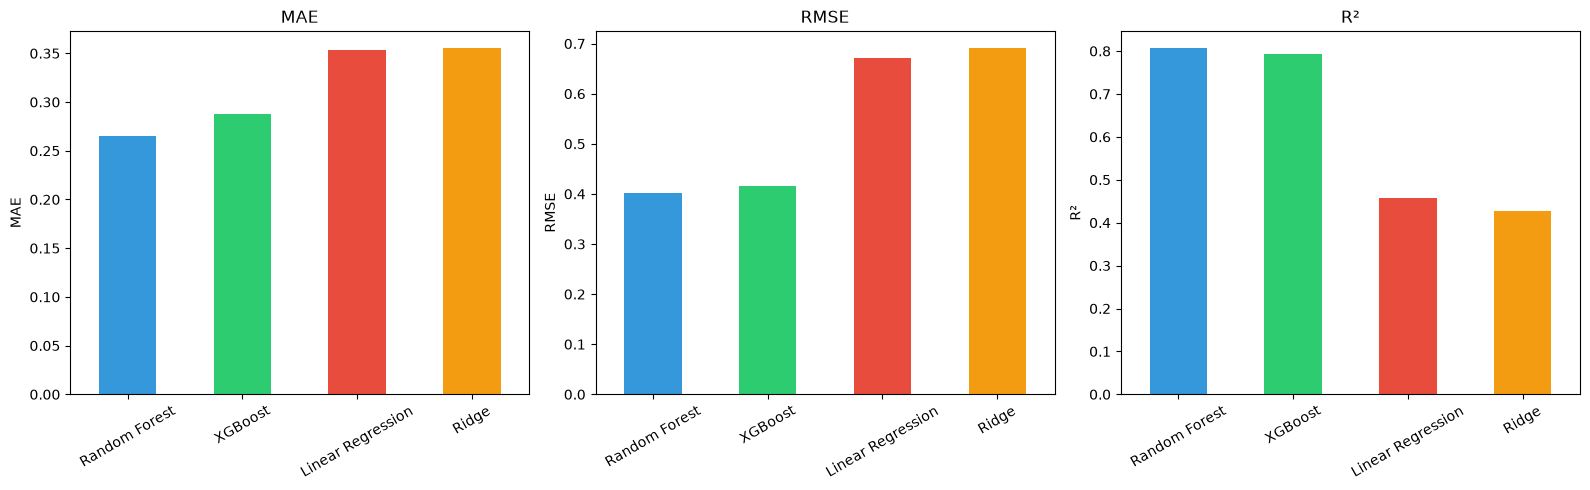

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metrika in enumerate(["MAE", "RMSE", "R²"]):
    rezultati_df[metrika].plot(kind="bar", ax=axes[i], color=["#3498db", "#2ecc71", "#e74c3c", "#f39c12"])
    axes[i].set_title(metrika)
    axes[i].set_ylabel(metrika)
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Najbolji model — Predicted vs Actual

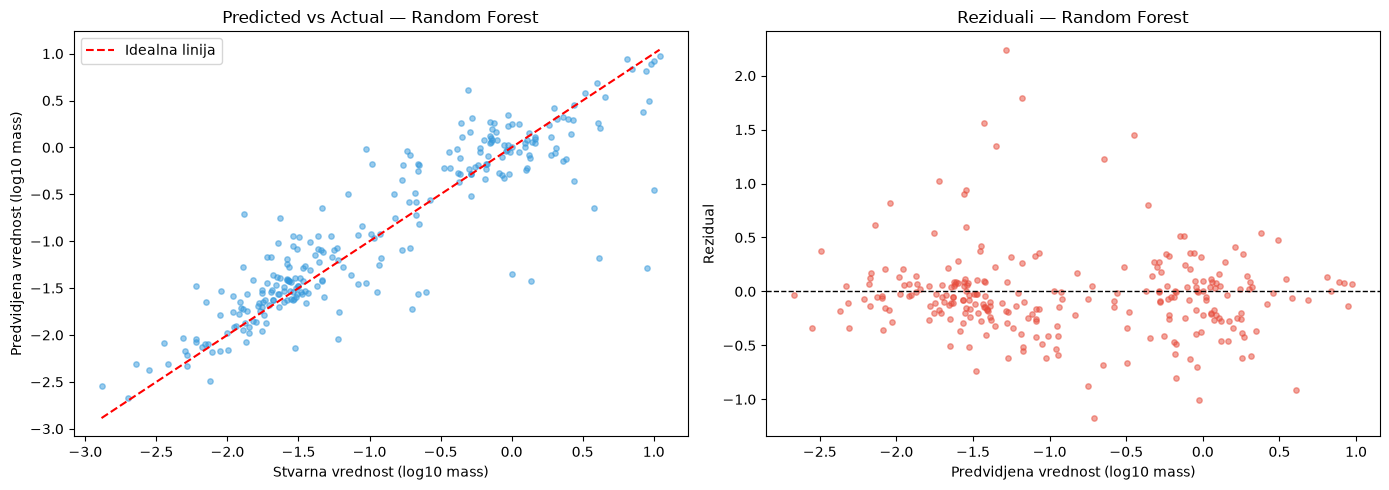

In [5]:
best_model = modeli[best_name]
y_pred_best = best_model.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, s=15, alpha=0.5, color="#3498db")
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Idealna linija")
axes[0].set_xlabel("Stvarna vrednost (log10 mass)")
axes[0].set_ylabel("Predvidjena vrednost (log10 mass)")
axes[0].set_title(f"Predicted vs Actual — {best_name}")
axes[0].legend()

# Reziduali
axes[1].scatter(y_pred_best, residuals, s=15, alpha=0.5, color="#e74c3c")
axes[1].axhline(y=0, color="black", lw=1, ls="--")
axes[1].set_xlabel("Predvidjena vrednost (log10 mass)")
axes[1].set_ylabel("Rezidual")
axes[1].set_title(f"Reziduali — {best_name}")

plt.tight_layout()
plt.show()

## 5. Cuvanje modela

In [6]:
for naziv, model in modeli.items():
    filename = naziv.lower().replace(" ", "_")
    joblib.dump(model, f"../models/{filename}.pkl")
    print(f"{naziv} sacuvan u models/{filename}.pkl")

Linear Regression sacuvan u models/linear_regression.pkl
Ridge sacuvan u models/ridge.pkl
Random Forest sacuvan u models/random_forest.pkl
XGBoost sacuvan u models/xgboost.pkl
